**INSTALAÇÃO E IMPORTS**

In [ ]:
'''Se estiver usando colab instale as bibliotecas abaixo com o comando !pip install <nome_da_biblioteca1> <nome_da_biblioteca2> <nome_da_biblioteca3>...'''

#Importanto bibliotecas
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

**LEITURA DO ARQUIVO E CRIAÇAO DO DF**

*Lembrar de copiar no caminho do arquivo csv na pasta base_dados


In [ ]:
df = pd.read_csv(r'C:\Users\marciohenrique\Documents\Projetos\github\ml_stat\bases_dados\base_imoveis.csv')

**EDA - ANÁLISE EXPLORATÓRIA DOS DADOS**

In [ ]:
df.info()
df.shape # olhando as dimensões da base
df.head() #lista as colunas e 5 linhas iniciais (visualiza a base)

**RESUMO ESTATÍSTICO**
Percepção inicial do comportamento dos dados

In [ ]:
df.describe()

**Separando categoricos e numéricos para o preprocessamento**

Fase de tratamento dos dados para inserir no 
- Definição das variáveis independentes(features)
- Definição da variável dependente (target)
- Aplicando tratamento de nulos para features pela mediana e moda
- Aplicando tratamento de nulos (drop) para o target



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # O pipeline garante que as mesmas transformações utilizadas no treinamento sejam aplicadas aos novos imóveis posteriormente.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

features = [
    "localidade",
    "tipo",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

target = "preco_venda"

numeric_features = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

categorical_features = [
    "localidade",
    "tipo"
]

df = df.dropna(subset=["preco_venda"]).copy() #Dropando nulos da variavel y

#Tratamento numerico
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")) # vamos usar a mediana para tratar os nulos numéricos
    ]
)

#tratamento categorico
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), #aqui usamos a moda para imputar o mais frequente p/ substituir nulos
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

X = df[features]
y = df[target]

**Percentual de treinamento**
- 0.20 é o que o modelo vai prever
- Os demais 0.8 o modelo vai treinar

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Preprocessamento**

In [ ]:
#Juntanto todo o processo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Aplicacação do método de regressão linear**

In [ ]:
#Algoritimo de RL
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

modelo_linear.fit(X_train, y_train)
#Agora com o que foi aprendido, vamos prever o preço de venda dos imóveis do conjunto de teste (X_test) e armazenar os resultados na variável y_pred_linear.
y_pred_linear = modelo_linear.predict(X_test) #comente esta linha se quiser ver o resultado do modelo, ou execute uma célula abaixo para ver o resultado do modelo.

**Indicadores de avaliação do modelo**\
MAE,RMSE,R²

In [ ]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )
mae_linear = mean_absolute_error( y_test, y_pred_linear )
rmse_linear = np.sqrt( mean_squared_error( y_test, y_pred_linear ) )
r2_linear = r2_score( y_test, y_pred_linear )

print(f"R²: {r2_linear:.4f}")
print(f"MAE : R$ {mae_linear:,.2f}") 
print(f"RMSE: R$ {rmse_linear:,.2f}") 
print(f"R² : {r2_linear:.4f}")

**Gráfico de Dispersão**

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter( y_test, y_pred_linear, alpha=0.5 )
plt.xlabel("Preço real") 
plt.ylabel("Preço previsto") 
plt.title("Preço real × preço previsto") 
plt.show()

**Questões:**

 Considerando que MAE é o erro médio, RMSE é penaliza mais esses erros,
- Qual é a intepretação de MAE?
- Qual é a interpretação de RMSE?
- Qual é a interpretação de R²
- É correto afirmar que o modelo acerta 82% dos preços? Justifique
- A diferença entre MAE e RMSE gera qual conclusão?
- Sob sua perpecpção o erro do modelo é aceitável para o mercado imobiliário?

**Retorne ao gráfico e responda**
- Qual faixa de preço o modelo mais acertou
- Qual faixa de preço houve erro e qual valor aproximado?



**Comparando Resultados em tela**

- Execute a tabela diferença e compare valor real e o valor previsto(y_test -y_pred_linear)
- O que significam o valores positivos e negativos da coluna diferença?

In [ ]:
#

tabela_diferenca = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred_linear,
    "Diferença": y_test-y_pred_linear,
    "Erro bruto": abs(y_test-y_pred_linear),
})
print(tabela_diferenca.head(10))

**Sugestões para discussão na próxima Aula**

- O que o gráfico abaixo sugere?

**Novos modelos e seus algoritmos**
Se possivel pesquise sobre arvore de decisão como é o princípio, qual a finidade e principais algoritimos e como elas podem ajudar uma imobiliária na classificação de imóveis ou clientes.

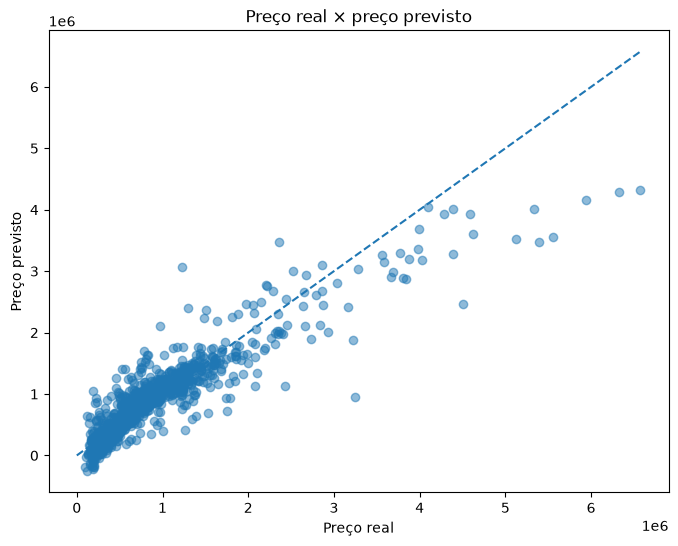

In [ ]:
"""plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

limite = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Preço real × preço previsto")

plt.show()"""